In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

df_yt_bert = pd.read_csv(
    r"C:\Users\Lucca\Documents\New project\nubank-sentiment-analysis\data\processed\youtube_with_predicted_sentiment_bertimbau.csv",
    encoding="utf-8"
)

print(df_yt_bert.shape)
print(df_yt_bert.columns.tolist())
print(df_yt_bert.head())

(13710, 13)
['id_registro', 'fonte', 'data_publicacao', 'titulo', 'texto_original', 'nota', 'usuario', 'categoria', 'status', 'sentimento_real', 'texto_limpo', 'data_processamento', 'sentimento_previsto_bert']
                  id_registro    fonte data_publicacao  \
0  Ugyp_WgMkcLUX7UklTV4AaABAg  youtube      2026-03-31   
1  UgyrWGL19PxSf6KhO9B4AaABAg  youtube      2026-03-31   
2  UgyZFRnEX8iRQEDnDtF4AaABAg  youtube      2026-03-31   
3  UgzIJfwlYy3oz7XoZv54AaABAg  youtube      2026-03-31   
4  UgyWTClPqf2Zfxocvtl4AaABAg  youtube      2026-03-31   

                                              titulo  \
0  NUBANK EMITE COMUNICADO OFICIAL PARA TODOS cli...   
1  Abrir Conta Nubank para menores de 18 anos   C...   
2  EMPRÉSTIMO SECRETO NUBANK TE DEIXA FAZER PIX M...   
3  CUIDADO: esses erros no NUBANK podem BLOQUEAR ...   
4  CUIDADO: esses erros no NUBANK podem BLOQUEAR ...   

                                      texto_original  nota  \
0              Sou cliente e sou muito bem

In [2]:
sent_dist = df_yt_bert["sentimento_previsto_bert"].value_counts()
sent_dist_pct = df_yt_bert["sentimento_previsto_bert"].value_counts(normalize=True) * 100

print(sent_dist)
print(sent_dist_pct.round(2))

sentimento_previsto_bert
Positivo    7987
Negativo    5626
Neutro        97
Name: count, dtype: int64
sentimento_previsto_bert
Positivo    58.26
Negativo    41.04
Neutro       0.71
Name: proportion, dtype: float64


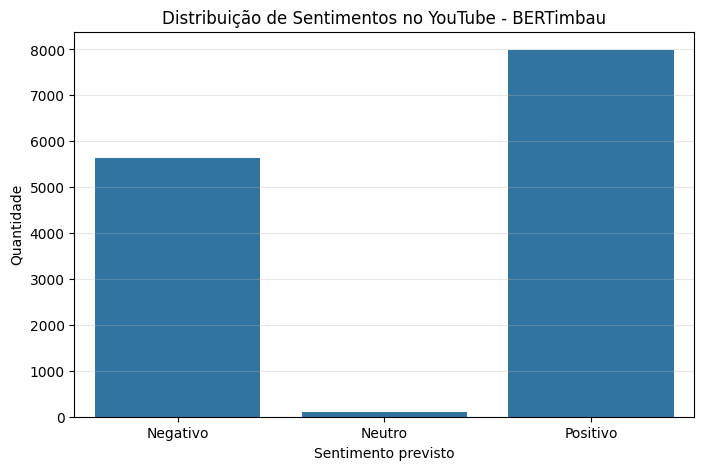

In [3]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_yt_bert,
    x="sentimento_previsto_bert",
    order=["Negativo", "Neutro", "Positivo"]
)
plt.title("Distribuição de Sentimentos no YouTube - BERTimbau")
plt.xlabel("Sentimento previsto")
plt.ylabel("Quantidade")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [4]:
for sentimento in ["Negativo", "Neutro", "Positivo"]:
    print(f"\n### {sentimento}")
    exemplos = df_yt_bert.loc[
        df_yt_bert["sentimento_previsto_bert"] == sentimento,
        ["texto_original", "texto_limpo"]
    ].head(10)
    print(exemplos.to_string(index=False))


### Negativo
                                                                                                                                                        texto_original                                                                                                                            texto_limpo
            Tenho conta nubank e não gostei pq só posso comprar comida, nem boneco nem nada de jogo, só comida, aí e ruim pq chega notificação no celular da minha mãe   tenho conta nubank nao gostei pq so posso comprar comida nem boneco nem nada jogo so comida ai ruim pq chega notificacao celular mae
A minha amiga quer pegar um dinheiro emprestado do unibank só que ela não sabe e ela tá me perguntando se corre juros pegando dinheiro emprestado no valor até de 1500 amiga quer pegar dinheiro emprestado unibank so ela nao sabe ela ta perguntando corre juros pegando dinheiro emprestado valor ate 1500
 Os endividados que eu conheço são os jogadores de apostas online, inclusive rol

In [5]:
for sentimento in ["Negativo", "Neutro", "Positivo"]:
    textos = df_yt_bert.loc[
        df_yt_bert["sentimento_previsto_bert"] == sentimento,
        "texto_limpo"
    ].dropna()

    tokens = " ".join(textos.astype(str)).split()
    freq = Counter(tokens)

    print(f"\n### {sentimento}")
    print(freq.most_common(20))


### Negativo
[('nao', 3191), ('banco', 1414), ('nubank', 1354), ('pra', 1179), ('conta', 1023), ('mais', 982), ('tem', 904), ('so', 900), ('dinheiro', 852), ('eles', 594), ('vai', 560), ('nada', 551), ('cartao', 545), ('limite', 468), ('tenho', 432), ('ta', 414), ('tudo', 403), ('mil', 396), ('ate', 388), ('bancos', 385)]

### Neutro
[('nao', 51), ('mais', 32), ('pra', 32), ('tem', 24), ('nubank', 22), ('muito', 19), ('emprestimo', 18), ('pago', 17), ('quando', 16), ('vc', 16), ('so', 15), ('vai', 15), ('mesmo', 15), ('voce', 14), ('dinheiro', 14), ('app', 13), ('ta', 13), ('juros', 13), ('mercado', 13), ('ate', 12)]

### Positivo
[('nao', 1778), ('nubank', 1567), ('banco', 1156), ('pra', 1005), ('tenho', 965), ('mais', 850), ('muito', 793), ('conta', 775), ('tem', 686), ('so', 641), ('cartao', 615), ('emprestimo', 568), ('dinheiro', 538), ('bom', 467), ('mil', 437), ('melhor', 437), ('video', 417), ('vai', 411), ('credito', 409), ('reais', 394)]


In [6]:
df_yt_bert["data_publicacao"] = pd.to_datetime(df_yt_bert["data_publicacao"], errors="coerce")
df_yt_bert["ano_mes"] = df_yt_bert["data_publicacao"].dt.to_period("M").astype(str)

yt_time = (
    df_yt_bert.groupby(["ano_mes", "sentimento_previsto_bert"])
    .size()
    .reset_index(name="quantidade")
)

print(yt_time.head())

   ano_mes sentimento_previsto_bert  quantidade
0  2025-10                 Negativo         502
1  2025-10                   Neutro          13
2  2025-10                 Positivo         606
3  2025-11                 Negativo         602
4  2025-11                   Neutro           8


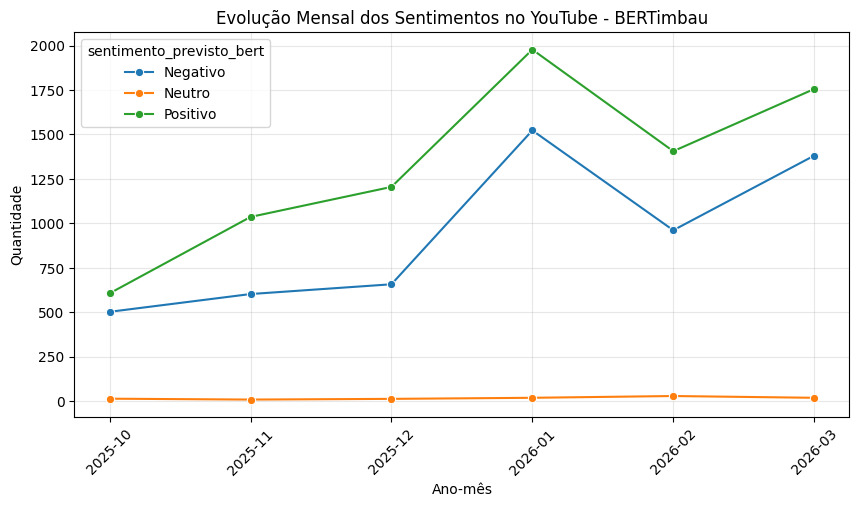

In [7]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=yt_time,
    x="ano_mes",
    y="quantidade",
    hue="sentimento_previsto_bert",
    hue_order=["Negativo", "Neutro", "Positivo"],
    marker="o"
)
plt.title("Evolução Mensal dos Sentimentos no YouTube - BERTimbau")
plt.xlabel("Ano-mês")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

In [8]:
summary_table = pd.DataFrame({
    "quantidade": sent_dist,
    "percentual": sent_dist_pct.round(2)
}).reset_index()

summary_table.columns = ["sentimento", "quantidade", "percentual"]
summary_table

,sentimento,quantidade,percentual
0,Positivo,7987,58.26
1,Negativo,5626,41.04
2,Neutro,97,0.71


In [9]:
summary_output = r"C:\Users\Lucca\Documents\New project\nubank-sentiment-analysis\data\processed\youtube_bert_sentiment_summary.csv"
summary_table.to_csv(summary_output, index=False, encoding="utf-8-sig")
print(summary_output)

C:\Users\Lucca\Documents\New project\nubank-sentiment-analysis\data\processed\youtube_bert_sentiment_summary.csv


In [10]:
summary_table = pd.DataFrame({
    "quantidade": df_yt_bert["sentimento_previsto_bert"].value_counts(),
    "percentual": (df_yt_bert["sentimento_previsto_bert"].value_counts(normalize=True) * 100).round(2)
}).reset_index()

summary_table.columns = ["sentimento", "quantidade", "percentual"]

summary_table = summary_table.sort_values(
    by="sentimento",
    key=lambda s: s.map({"Negativo": 0, "Neutro": 1, "Positivo": 2})
).reset_index(drop=True)

summary_table

,sentimento,quantidade,percentual
0,Negativo,5626,41.04
1,Neutro,97,0.71
2,Positivo,7987,58.26


In [11]:
summary_output = r"C:\Users\Lucca\Documents\New project\nubank-sentiment-analysis\data\processed\youtube_bert_sentiment_summary.csv"
summary_table.to_csv(summary_output, index=False, encoding="utf-8-sig")
print(summary_output)

C:\Users\Lucca\Documents\New project\nubank-sentiment-analysis\data\processed\youtube_bert_sentiment_summary.csv


In [12]:
df_yt_bert["data_publicacao"] = pd.to_datetime(df_yt_bert["data_publicacao"], errors="coerce")
df_yt_bert["ano_mes"] = df_yt_bert["data_publicacao"].dt.to_period("M").astype(str)

yt_time = (
    df_yt_bert.groupby(["ano_mes", "sentimento_previsto_bert"])
    .size()
    .reset_index(name="quantidade")
)

print(yt_time.head(20))

    ano_mes sentimento_previsto_bert  quantidade
0   2025-10                 Negativo         502
1   2025-10                   Neutro          13
2   2025-10                 Positivo         606
3   2025-11                 Negativo         602
4   2025-11                   Neutro           8
5   2025-11                 Positivo        1036
6   2025-12                 Negativo         657
7   2025-12                   Neutro          12
8   2025-12                 Positivo        1205
9   2026-01                 Negativo        1523
10  2026-01                   Neutro          18
11  2026-01                 Positivo        1978
12  2026-02                 Negativo         961
13  2026-02                   Neutro          28
14  2026-02                 Positivo        1406
15  2026-03                 Negativo        1381
16  2026-03                   Neutro          18
17  2026-03                 Positivo        1756


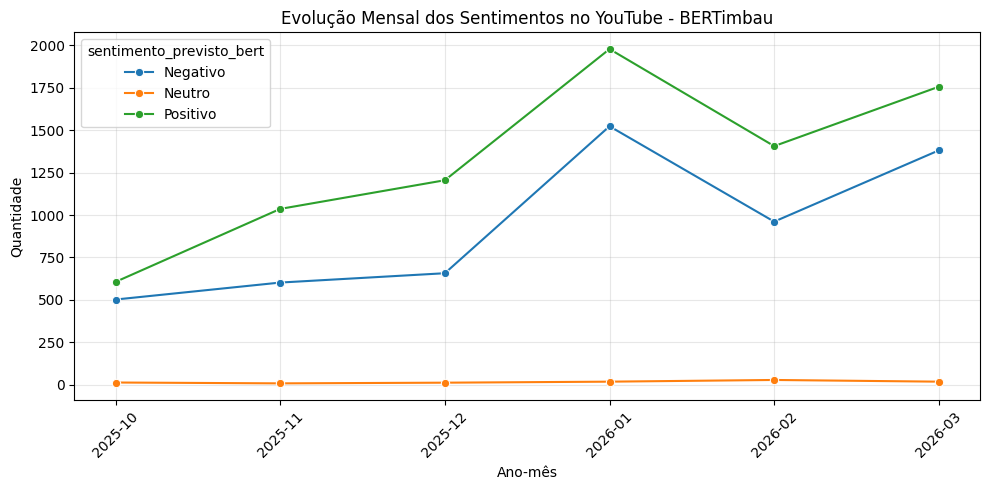

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=yt_time,
    x="ano_mes",
    y="quantidade",
    hue="sentimento_previsto_bert",
    hue_order=["Negativo", "Neutro", "Positivo"],
    marker="o"
)

plt.title("Evolução Mensal dos Sentimentos no YouTube - BERTimbau")
plt.xlabel("Ano-mês")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

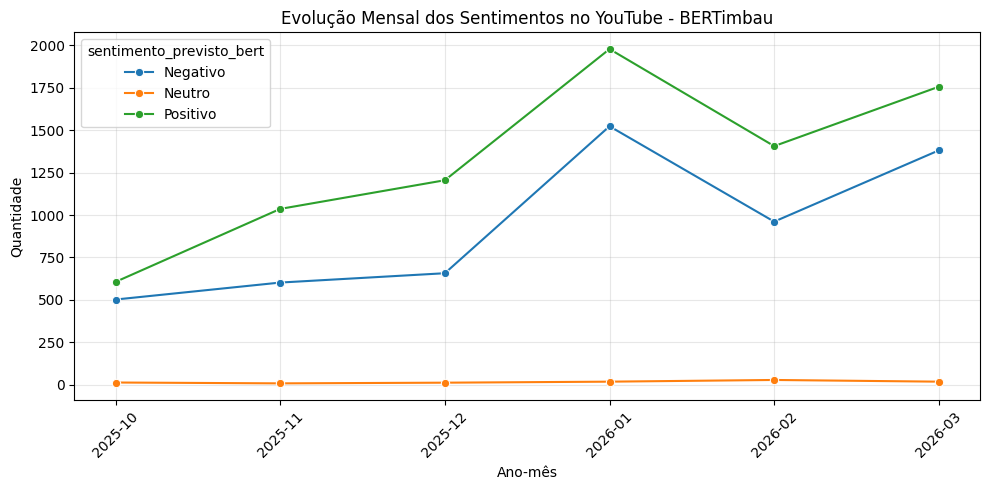

C:\Users\Lucca\Documents\New project\nubank-sentiment-analysis\data\processed\youtube_bert_sentiment_over_time.png


In [14]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=yt_time,
    x="ano_mes",
    y="quantidade",
    hue="sentimento_previsto_bert",
    hue_order=["Negativo", "Neutro", "Positivo"],
    marker="o"
)

plt.title("Evolução Mensal dos Sentimentos no YouTube - BERTimbau")
plt.xlabel("Ano-mês")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

chart_output = r"C:\Users\Lucca\Documents\New project\nubank-sentiment-analysis\data\processed\youtube_bert_sentiment_over_time.png"
plt.savefig(chart_output, dpi=300, bbox_inches="tight")
plt.show()

print(chart_output)